In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [248]:
df = pd.read_csv("el_nino.csv")
df.dropna(thresh=10, inplace=True)
df


,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24
1,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97
2,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28
3,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31
4,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19
...,...,...,...,...,...,...,...,...,...,...,...
178074,98,6,10,980610,8.95,-140.33,-6.8,-5.3,81.3,27.52,28.17
178075,98,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14
178076,98,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87
178077,98,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93


/tmp/ipykernel_70/890929039.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly['date'] = pd.to_datetime(


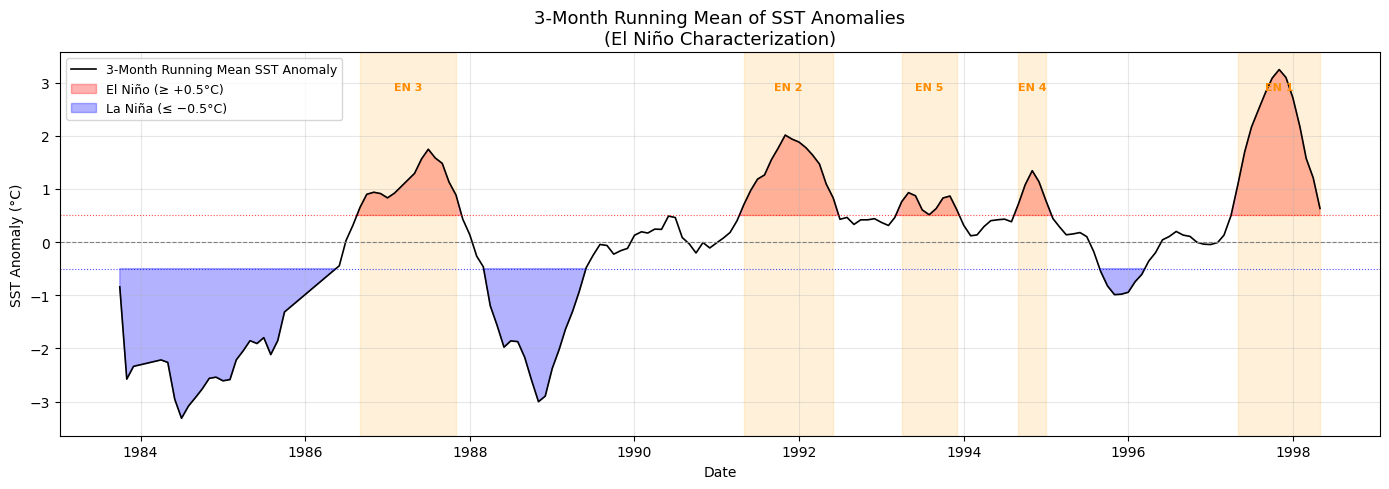


Top 5 Consecutive El Niño Periods (by peak anomaly):
     start        end     peak
1997-05-01 1998-05-01 3.244780
1991-05-01 1992-06-01 2.012413
1986-09-01 1987-11-01 1.745821
1994-09-01 1995-01-01 1.342093
1993-04-01 1993-12-01 0.929828


In [251]:
df = df.sort_values('date')

df = df[
    (df["latitude"].between(-5, 5)) &
    (df["longitude"].between(-170, -120))
]


# --- Step 1: Compute monthly mean SST (averaged across all lat/lon per month) ---
monthly = (
    df.groupby(['year', 'month'])['ss_temp']
    .mean()
    .reset_index()
    .sort_values(['year', 'month'])
)

# Build datetime index
monthly['date'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
)
monthly = monthly.set_index('date')

# --- Step 2: Compute SST anomaly by subtracting long-term monthly climatology ---
climatology = monthly.groupby('month')['ss_temp'].mean()
monthly['sst_anom'] = monthly.apply(lambda row: row['ss_temp'] - climatology[row['month']], axis=1)

# --- Step 3: 3-month centered rolling mean ---
monthly['sst_3mo_mean'] = monthly['sst_anom'].rolling(window=3, center=True).mean()

# --- Threshold ---
THRESHOLD = 0.5

# --- Step 4: Identify top 5 consecutive El Niño periods ---
monthly['el_nino'] = monthly['sst_3mo_mean'] >= THRESHOLD
monthly['run_id'] = (monthly['el_nino'] != monthly['el_nino'].shift()).cumsum()

runs = (
    monthly[monthly['el_nino']]
    .groupby('run_id')
    .agg(
        start=('sst_3mo_mean', lambda s: s.index[0]),
        end=('sst_3mo_mean', lambda s: s.index[-1]),
        peak=('sst_3mo_mean', 'max')
    )
    .sort_values('peak', ascending=False)
    .head(5)
)

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

x = monthly.index
y = monthly['sst_3mo_mean']

ax.plot(x, y, color='black', linewidth=1.2, label='3-Month Running Mean SST Anomaly')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline( THRESHOLD, color='red',  linewidth=0.8, linestyle=':', alpha=0.7)
ax.axhline(-THRESHOLD, color='blue', linewidth=0.8, linestyle=':', alpha=0.7)

ax.fill_between(x, y,  THRESHOLD, where=(y >=  THRESHOLD), interpolate=True, color='red',  alpha=0.3, label='El Niño (≥ +0.5°C)')
ax.fill_between(x, y, -THRESHOLD, where=(y <= -THRESHOLD), interpolate=True, color='blue', alpha=0.3, label='La Niña (≤ −0.5°C)')

for i, (_, row) in enumerate(runs.iterrows()):
    ax.axvspan(row['start'], row['end'], color='orange', alpha=0.15)
    mid = row['start'] + (row['end'] - row['start']) / 2
    ax.text(mid, y.max() * 0.88, f'EN {i+1}',
            ha='center', fontsize=8, color='darkorange', fontweight='bold')

ax.set_title('3-Month Running Mean of SST Anomalies\n(El Niño Characterization)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('SST Anomaly (°C)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Print the 5 highlighted El Niño episodes ---
print("\nTop 5 Consecutive El Niño Periods (by peak anomaly):")
print(runs[['start', 'end', 'peak']].to_string(index=False))

In [252]:
df["year"] = df["year"] + 1900

monthly_label = monthly["el_nino"].astype(int).reset_index()
monthly_label["year"] = monthly_label["date"].dt.year
monthly_label["month"] = monthly_label["date"].dt.month
monthly_label = monthly_label[["year","month","el_nino"]]

df = df.merge(monthly_label, on=["year","month"], how="left")
df["el_nino"] = df["el_nino"].fillna(0).astype(int)

In [253]:
print(df["el_nino"].value_counts())

el_nino
0    19581
1    14589
Name: count, dtype: int64


In [254]:
df[df["el_nino"]==1].head(5)

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp,el_nino
856,1986,9,1,860901,-2.11,-140.03,-7.4,1.0,NaN,26.61,27.02,1
857,1986,9,1,860901,-0.02,-140.02,-7.8,0.1,NaN,26.46,26.64,1
858,1986,9,2,860902,-0.02,-140.02,-7.8,2.7,NaN,26.56,26.62,1
859,1986,9,2,860902,-2.11,-140.03,-7.7,2.2,NaN,26.67,27.02,1
860,1986,9,3,860903,-0.02,-140.02,-8.0,0.9,NaN,26.57,26.55,1


In [255]:
features = [
    "zon_winds",
    "mer_winds",
    "humidity",
    "air_temp",
    "latitude",
    "longitude",
    "month"
]

target = "el_nino"

In [256]:
cutoff = 960101
train = df[df["date"] < cutoff]
test  = df[df["date"] >= cutoff]


X_train = train[features]
y_train = train[target]

In [259]:
print("Train:\n", train[target].value_counts())
print("Test:\n", test[target].value_counts())

Train:
 el_nino
0    13920
1     9474
Name: count, dtype: int64
Test:
 el_nino
0    5661
1    5115
Name: count, dtype: int64


In [262]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('sc', StandardScaler()),
                ('lr', LogisticRegression(max_iter=2000))])

In [265]:
from sklearn.metrics import roc_auc_score, classification_report

proba = model.predict_proba(X_test)[:,1]
pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

ROC AUC: 0.9227942104602446
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      5661
           1       0.83      0.85      0.84      5115

    accuracy                           0.85     10776
   macro avg       0.85      0.85      0.85     10776
weighted avg       0.85      0.85      0.85     10776



In [266]:

monthly_label = monthly[["el_nino"]].copy()
monthly_label["el_nino_future3"] = monthly_label["el_nino"].shift(-3)

monthly_label = monthly_label.reset_index()
monthly_label["year"] = monthly_label["date"].dt.year
monthly_label["month"] = monthly_label["date"].dt.month
monthly_label = monthly_label[["year","month","el_nino_future3"]].dropna()

df = df.merge(monthly_label, on=["year","month"], how="inner")
df["el_nino_future3"] = df["el_nino_future3"].astype(int)
target = "el_nino_future3"
cutoff = 960101
train = df[df["date"] < cutoff].copy()
test  = df[df["date"] >= cutoff].copy()

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print("Train:\n", y_train.value_counts())
print("Test:\n", y_test.value_counts())

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

Train:
 el_nino_future3
0    15053
1     8341
Name: count, dtype: int64
Test:
 el_nino_future3
1    5158
0    4671
Name: count, dtype: int64


Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('sc', StandardScaler()),
                ('lr', LogisticRegression(max_iter=2000))])

In [269]:
from sklearn.metrics import roc_auc_score, classification_report

proba = model.predict_proba(X_test)[:,1]
pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

ROC AUC: 0.8657792477472104
              precision    recall  f1-score   support

           0       0.71      0.90      0.80      4671
           1       0.88      0.67      0.76      5158

    accuracy                           0.78      9829
   macro avg       0.80      0.79      0.78      9829
weighted avg       0.80      0.78      0.78      9829



In [272]:
baseline = test["el_nino"]  # current label
print("Persistence AUC:",
      roc_auc_score(y_test, baseline))

Persistence AUC: 0.8456731323572664


In [273]:
#six months

In [276]:
monthly_label = monthly[["el_nino"]].copy()
monthly_label["el_nino_future6"] = monthly_label["el_nino"].shift(-6)

monthly_label = monthly_label.reset_index()
monthly_label["year"] = monthly_label["date"].dt.year
monthly_label["month"] = monthly_label["date"].dt.month
monthly_label = monthly_label[["year","month","el_nino_future6"]].dropna()

In [277]:
df6 = df.merge(monthly_label, on=["year","month"], how="inner")
df6["el_nino_future6"] = df6["el_nino_future6"].astype(int)

In [278]:
target = "el_nino_future6"

train = df6[df6["date"] < cutoff].copy()
test  = df6[df6["date"] >= cutoff].copy()

X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]

In [279]:
model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('sc', StandardScaler()),
                ('lr', LogisticRegression(max_iter=2000))])

In [280]:
proba = model.predict_proba(X_test)[:,1]
pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

ROC AUC: 0.6775524591352163
              precision    recall  f1-score   support

           0       0.42      0.89      0.57      3459
           1       0.73      0.20      0.32      5245

    accuracy                           0.48      8704
   macro avg       0.58      0.55      0.45      8704
weighted avg       0.61      0.48      0.42      8704



In [281]:
baseline6 = test["el_nino"]  # current ENSO state
print("Persistence AUC (6mo):",
      roc_auc_score(y_test, baseline6))

Persistence AUC (6mo): 0.708494467810448


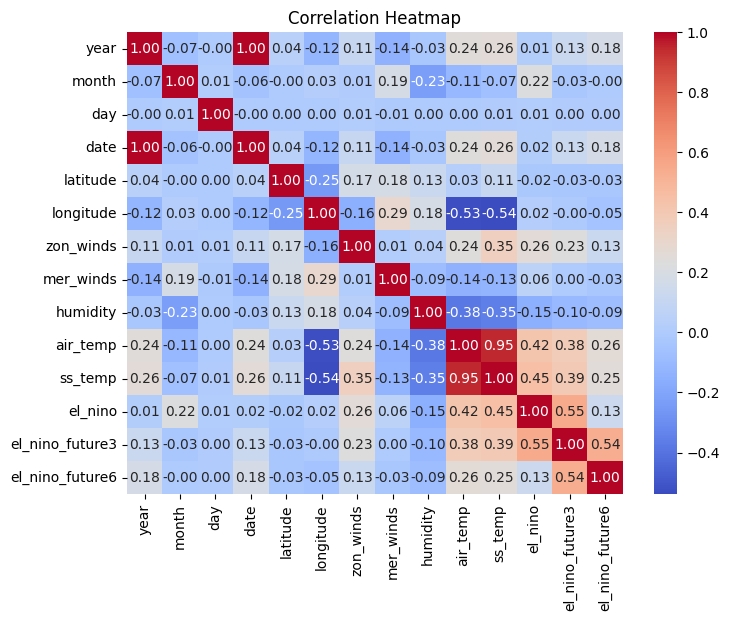

In [282]:
correlation_matrix = pd.DataFrame(df6).corr()
# Create the heatmap
plt.figure(figsize=(8, 6)) # Adjust the size of the plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f") # Use seaborn.heatmap
plt.title('Correlation Heatmap') # Add a title
plt.show() # Display the plot

In [283]:
df['year'].unique()

array([1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998])

In [284]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# ============================================================
# 0) ASSUMPTION: df already exists in your notebook
#    Must have: date, el_nino, zon_winds, air_temp, latitude, longitude
# ============================================================

# -----------------------------
# 1) Build a proper month key
# -----------------------------
# If date is yymmdd (like 960101), convert to datetime
if np.issubdtype(df["date"].dtype, np.number):
    d = df["date"].astype(int)
    yy = d // 10000
    mm = (d // 100) % 100
    dd = d % 100
    yyyy = np.where(yy >= 50, 1900 + yy, 2000 + yy)   # 96->1996 etc.
    df["_date_dt"] = pd.to_datetime(
        pd.DataFrame({"year": yyyy, "month": mm, "day": dd}),
        errors="coerce"
    )
else:
    df["_date_dt"] = pd.to_datetime(df["date"], errors="coerce")

df["_ym"] = df["_date_dt"].dt.to_period("M").dt.to_timestamp()  # monthly timestamp

# -----------------------------
# 2) Basin monthly averages
#    (average across all gridpoints each month)
# -----------------------------
agg_cols = ["zon_winds", "air_temp"]
optional_cols = ["mer_winds", "humidity", "sst", "sst_anom", "nino34", "nino3_4", "elnino_sst"]
for c in optional_cols:
    if c in df.columns:
        agg_cols.append(c)

# Monthly means of predictors
monthly = df.groupby("_ym", as_index=False)[agg_cols].mean()

# Monthly label: el_nino as majority vote across gridpoints in that month
# (mean is fraction of gridpoints flagged; threshold at 0.5)
el_month = df.groupby("_ym")["el_nino"].mean().reset_index()
monthly = monthly.merge(el_month, on="_ym", how="left")
monthly["el_nino"] = (monthly["el_nino"] >= 0.5).astype(int)

monthly = monthly.sort_values("_ym").reset_index(drop=True)

# -----------------------------
# 3) Rolling SST trend (if we have an SST-like column)
#    We'll create:
#      - sst_ma3: 3-mo mean
#      - sst_d1:  1-mo change
#      - sst_d3:  3-mo change
# -----------------------------
sst_like = None
for c in ["sst_anom", "sst", "nino34", "nino3_4", "elnino_sst"]:
    if c in monthly.columns:
        sst_like = c
        break

if sst_like is not None:
    monthly[f"{sst_like}_ma3"] = monthly[sst_like].rolling(3).mean()
    monthly[f"{sst_like}_d1"]  = monthly[sst_like].diff(1)
    monthly[f"{sst_like}_d3"]  = monthly[sst_like].diff(3)
else:
    print("NOTE: No SST-like column found (sst/sst_anom/nino34/etc). Skipping SST trend features.")

# -----------------------------
# 4) Seasonality features (month-of-year as sin/cos)
# -----------------------------
m = monthly["_ym"].dt.month
monthly["month_sin"] = np.sin(2*np.pi*m/12)
monthly["month_cos"] = np.cos(2*np.pi*m/12)

# -----------------------------
# 5) Future target + change target on the MONTHLY series
# -----------------------------
H = 6  # set 3 for 3-month ahead

monthly["el_nino_future"] = monthly["el_nino"].shift(-H)
monthly["did_change"] = (monthly["el_nino_future"] != monthly["el_nino"]).astype(int)

# -----------------------------
# 6) Feature set
# -----------------------------
features = ["zon_winds", "air_temp", "month_sin", "month_cos"]

# add optional aggregated predictors if present
for c in ["mer_winds", "humidity"]:
    if c in monthly.columns:
        features.append(c)

# add SST trend features if present
if sst_like is not None:
    features += [sst_like, f"{sst_like}_ma3", f"{sst_like}_d1", f"{sst_like}_d3"]

# drop rows with NaNs from rolling/shift
model_df = monthly.dropna(subset=features + ["el_nino_future", "did_change"]).copy()

# -----------------------------
# 7) Time split (same cutoff idea: 1996-01-01)
# -----------------------------
cutoff_dt = pd.Timestamp("1996-01-01")
train = model_df[model_df["_ym"] < cutoff_dt]
test  = model_df[model_df["_ym"] >= cutoff_dt]

X_train, X_test = train[features], test[features]

# -----------------------------
# 8) Train logistic: FUTURE STATE + compare to persistence
# -----------------------------
pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

y_train_future = train["el_nino_future"].astype(int)
y_test_future  = test["el_nino_future"].astype(int)

pipe.fit(X_train, y_train_future)
p_future = pipe.predict_proba(X_test)[:, 1]
pred_future = (p_future >= 0.5).astype(int)

print(f"\n=== MONTHLY BASIN FUTURE STATE (H={H}) ===")
print("Logistic AUC:", roc_auc_score(y_test_future, p_future))

# persistence baseline (monthly): predict future = current
p_persist = test["el_nino"].values.astype(float)
print("Persistence AUC:", roc_auc_score(y_test_future, p_persist))
print(classification_report(y_test_future, pred_future))

# -----------------------------
# 9) Train logistic: REGIME CHANGE + compare to always-no-change
# -----------------------------
y_train_change = train["did_change"].astype(int)
y_test_change  = test["did_change"].astype(int)

pipe.fit(X_train, y_train_change)
p_change = pipe.predict_proba(X_test)[:, 1]
pred_change = (p_change >= 0.5).astype(int)

print(f"\n=== MONTHLY BASIN REGIME CHANGE (H={H}) ===")
print("Logistic AUC:", roc_auc_score(y_test_change, p_change))

# baseline for change = always 0
if y_test_change.nunique() == 2:
    print("Always-no-change AUC:", roc_auc_score(y_test_change, np.zeros_like(y_test_change, dtype=float)))
print(classification_report(y_test_change, pred_change))

monthly.head()

NOTE: No SST-like column found (sst/sst_anom/nino34/etc). Skipping SST trend features.

=== MONTHLY BASIN FUTURE STATE (H=6) ===
Logistic AUC: 0.8909090909090909
Persistence AUC: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.89      0.73      0.80        11

    accuracy                           0.81        21
   macro avg       0.82      0.81      0.81        21
weighted avg       0.82      0.81      0.81        21


=== MONTHLY BASIN REGIME CHANGE (H=6) ===
Logistic AUC: 0.9
Always-no-change AUC: 0.5
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        15
           1       0.50      1.00      0.67         6

    accuracy                           0.71        21
   macro avg       0.75      0.80      0.71        21
weighted avg       0.86      0.71      0.73        21



,_ym,zon_winds,air_temp,mer_winds,humidity,el_nino,month_sin,month_cos,el_nino_future,did_change
0,1983-04-01,-1.100000,28.396000,-2.000000,NaN,0,8.660254e-01,-0.500000,0.0,0
1,1983-10-01,-5.936364,23.776364,0.154545,NaN,0,-8.660254e-01,0.500000,0.0,0
2,1983-11-01,-5.880000,23.889333,0.123333,NaN,0,-5.000000e-01,0.866025,0.0,0
3,1983-12-01,-5.518182,23.691818,0.009091,NaN,0,-2.449294e-16,1.000000,0.0,0
4,1984-04-01,-2.236364,25.858182,-0.418182,NaN,0,8.660254e-01,-0.500000,0.0,0


In [287]:
monthly = monthly.sort_values("_ym").reset_index(drop=True)

H = 6

y_t = monthly["el_nino"]
y_t6 = y_t.shift(-H)

valid = ~y_t6.isna()

corr_6 = np.corrcoef(y_t[valid], y_t6[valid])[0,1]

print("6-month autocorrelation:", corr_6)
print("Squared (R^2 equivalent):", corr_6**2)

6-month autocorrelation: 0.2308697214899094
Squared (R^2 equivalent): 0.05330082830082833


In [290]:
H = 3

y_t3 = monthly["el_nino"].shift(-H)
valid = ~y_t3.isna()

corr_3 = np.corrcoef(monthly["el_nino"][valid], y_t3[valid])[0,1]

print("3-month autocorrelation:", corr_3)
print("Squared:", corr_3**2)

3-month autocorrelation: 0.610118911795725
Squared: 0.37224508653079963


In [293]:
print("Persistence accuracy 6mo:",
      (monthly["el_nino"] ==
       monthly["el_nino"].shift(-6)).mean())

Persistence accuracy 6mo: 0.6441717791411042


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=3e923cdf-80c4-4695-992d-68dfa4aaa3d0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>